## EDA Experiment Checklist

### Abstract / Mental Model
	1.	Is treatment coded correctly?
	2.	Are groups balanced?
	3.	Do pre-period trends differ?
	4.	Is naïve lift plausible?
	5.	What assumptions will modeling require?


### Checklist
1. Define the Estimand
2. Treatment Integrity Checks
3. Selection Bias Diagnostics (Balance Check) / Standardized Mean Differences
4. Pre-Treatment Outcome Comparison
5. Naive Outcome Difference
6. Economic Sanity Checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

# Read in synthetic data

df = pd.read_csv("data/raw/project_google_synth.csv")
df.head()

,user_id,date,dow,post,exposed,treated_group,discount_pct,region,device_type,traffic_source,...,list_price,gross_sales_pre_discount,net_revenue,unit_cost,total_cost,margin_dollars,margin_rate,counterfactual_units,counterfactual_revenue,counterfactual_margin_dollars
0,0,2025-11-01,5,0,0,0,0.0,South,Desktop,Email,...,16.856929,16.856929,16.856929,11.017525,11.017525,5.839403,0.34641,1,16.856929,5.839403
1,0,2025-11-02,6,0,0,0,0.0,South,Desktop,Email,...,16.856929,33.713857,33.713857,11.017525,22.035051,11.678807,0.34641,2,33.713857,11.678807
2,0,2025-11-03,0,0,0,0,0.0,South,Desktop,Email,...,16.856929,0.000000,0.000000,11.017525,0.000000,0.000000,0.00000,0,0.000000,0.000000
3,0,2025-11-04,1,0,0,0,0.0,South,Desktop,Email,...,16.856929,33.713857,33.713857,11.017525,22.035051,11.678807,0.34641,2,33.713857,11.678807
4,0,2025-11-05,2,0,0,0,0.0,South,Desktop,Email,...,16.856929,16.856929,16.856929,11.017525,11.017525,5.839403,0.34641,1,16.856929,5.839403


### 1. Define the Estimand

	•	Treatment: exposed
	•	Outcome (primary): margin_dollars
	•	Secondary: net_revenue
	•	Unit of analysis: user-day
	•	Estimand: ATT (impact on exposed users)

### 2. Treatment Integrity Checks

In [6]:
# Check exposure rates
print("Expect: Pre-period exposure ≈ 0")  
print("Expect: Promo-period exposure > 0")
print("-"*25)
print(df.groupby("post")["exposed"].mean())

Expect: Pre-period exposure ≈ 0
Expect: Promo-period exposure > 0
-------------------------
post
0    0.00000
1    0.72612
Name: exposed, dtype: float64


In [7]:
# Check discount only applied when exposed
print("Expectation: exposed=0 → 0")
print("Expectation: exposed=1 → ~0.40")
print("-"*25)
df.groupby("exposed")["discount_pct"].mean()

Expectation: exposed=0 → 0
Expectation: exposed=1 → ~0.40
-------------------------


exposed
0    0.0
1    0.4
Name: discount_pct, dtype: float64

### 3. Selection Bias Diagnostics (Balance Check)  
Restrict to Promo Window

In [10]:
promo = df[df["post"] == 1].copy()
print("if different, then selection bias")
print("_"*25)
print(promo.groupby("exposed")[[
    "prior_30d_spend",
    "engagement_score",
    "tenure_days"
]].mean())


if different, then selection bias
_________________________
         prior_30d_spend  engagement_score  tenure_days
exposed                                                
0              57.952926         -0.194221   220.431430
1              79.982772          0.061620   227.257946


Standardized Mean Difference 

In [14]:
def smd(x_treated, x_control):
    return (x_treated.mean() - x_control.mean()) / np.sqrt(
        (x_treated.var() + x_control.var()) / 2
    )

treated = promo[promo["exposed"] == 1]
control = promo[promo["exposed"] == 0]

print("Rule of thumb:\n0.1 small\n0.2 moderate\n0.5 large imbalance")
print("-"*25)

print("SMD prior spend:", smd(treated["prior_30d_spend"], control["prior_30d_spend"]))
print("SMD engagement:", smd(treated["engagement_score"], control["engagement_score"]))

Rule of thumb:
0.1 small
0.2 moderate
0.5 large imbalance
-------------------------
SMD prior spend: 0.27063688969693234
SMD engagement: 0.2582182289947123


### 4. Pre-Treatment Outcome Comparison

In [29]:
pre = df[df["post"] == 0].copy()
print("Prior to the promo window\nMean margin dollars of treated users")
print("-"*25)
print("Pre promo margin dollars of treated users\n",pre.groupby("exposed")["margin_dollars"].mean())

Prior to the promo window
Mean margin dollars of treated users
-------------------------
Pre promo margin dollars of treated users
 exposed
0    4.377309
Name: margin_dollars, dtype: float64


In [35]:
# Mark users who will be exposed in promo
treated_users = promo[promo["exposed"] == 1]["user_id"].unique()

pre["ever_exposed"] = pre["user_id"].isin(treated_users).astype(int)

print("This checks whether treated users were already stronger before promo.")
print("If yes, then supports selection bias diagnosis")
print("NOTE: treated users margin slightly lower than above as not all pre promo treated participated ")
print("-"*25)
print(pre.groupby("ever_exposed")["margin_dollars"].mean())
print("Treated group has higher margin pre promo than control - not exposed group")


This checks whether treated users were already stronger before promo.
If yes, then supports selection bias diagnosis
NOTE: treated users margin slightly lower than above as not all pre promo treated participated 
-------------------------
ever_exposed
0    3.314823
1    4.380827
Name: margin_dollars, dtype: float64
Treated group has higher margin pre promo than control - not exposed group


### 5. Naive Outcome Differences

In [37]:
print(promo.groupby("exposed")["margin_dollars"].mean())
print("-"*25)
print("The non treated users have a higher margin due to no discount")

exposed
0    4.922747
1   -0.682538
Name: margin_dollars, dtype: float64
-------------------------
The non treated users have a higher margin due to no discount


In [39]:
naive_lift = (
    promo[promo["exposed"]==1]["margin_dollars"].mean()
    - promo[promo["exposed"]==0]["margin_dollars"].mean()
)
print("Naive Lift or Unadjusted difference in margin: ", naive_lift)

Naive Lift or Unadjusted difference in margin:  -5.605284638935568


### 6. Economic Sanity Checks

In [41]:
print("Look for:\nUnits higher for exposed\nRevenue higher for exposed\nMargin rate lower for exposed")

promo.groupby("exposed")[[
    "units",
    "net_revenue",
    "margin_dollars",
    "margin_rate"
]].mean()

Look for:
Units higher for exposed
Revenue higher for exposed
Margin rate lower for exposed


,units,net_revenue,margin_dollars,margin_rate
exposed,,,,
0,0.482328,13.265305,4.922747,0.119493
1,0.793918,13.027475,-0.682538,-0.035387


### 7. Plot Pre vs. Post Daily Margin for Non Exposed vs. Exposed

In [44]:
promo = df[df["post"] == 1]
treated_users = promo[promo["exposed"] == 1]["user_id"].unique()

df["ever_exposed"] = df["user_id"].isin(treated_users).astype(int)

daily_margin = (
    df.groupby(["date", "ever_exposed"])["margin_dollars"]
      .mean()
      .reset_index()
)

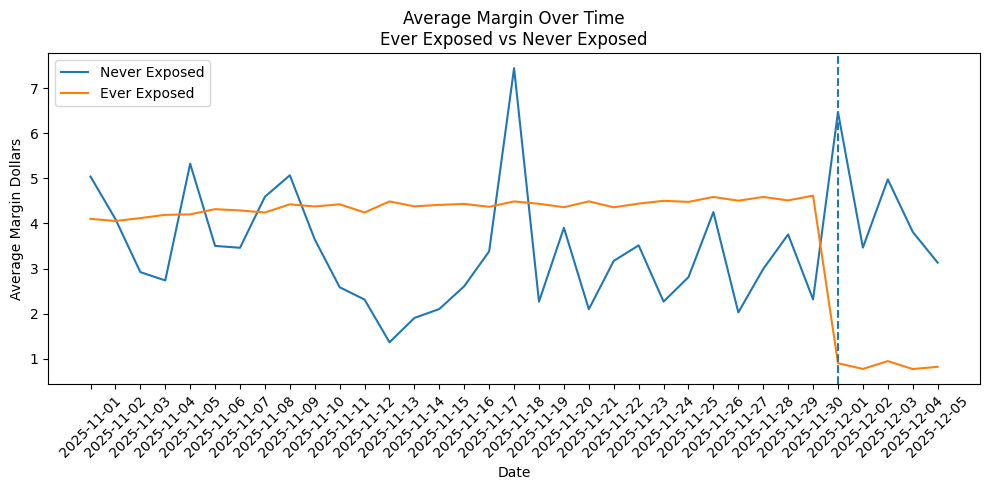

In [45]:
plt.figure(figsize=(10, 5))

for group in [0, 1]:
    subset = daily_margin[daily_margin["ever_exposed"] == group]
    label = "Never Exposed" if group == 0 else "Ever Exposed"
    plt.plot(subset["date"], subset["margin_dollars"], label=label)

plt.axvline(df["date"].iloc[30], linestyle="--")  # promo start (adjust if needed)

plt.title("Average Margin Over Time\nEver Exposed vs Never Exposed")
plt.xlabel("Date")
plt.ylabel("Average Margin Dollars")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Why Is Never-Exposed More Volatile?

Likely reasons:  
	•	Smaller group size (since 72% were exposed during promo)  
	•	Lower baseline margin  
	•	Higher relative variance because of more zero-margin days  

Remember:  

If mean margin is ~3–4 dollars,  
a few high purchases will spike the average.  

That’s expected in retail-like simulations.

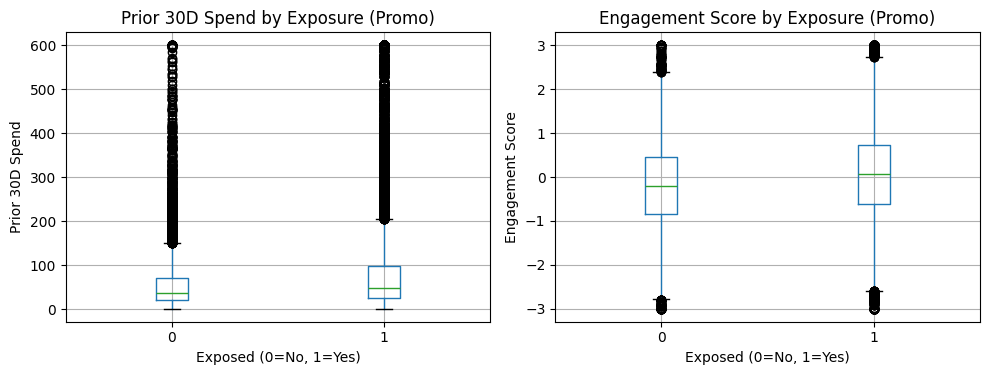

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

promo.boxplot(column="prior_30d_spend", by="exposed", ax=axes[0])
axes[0].set_title("Prior 30D Spend by Exposure (Promo)")
axes[0].set_xlabel("Exposed (0=No, 1=Yes)")
axes[0].set_ylabel("Prior 30D Spend")

promo.boxplot(column="engagement_score", by="exposed", ax=axes[1])
axes[1].set_title("Engagement Score by Exposure (Promo)")
axes[1].set_xlabel("Exposed (0=No, 1=Yes)")
axes[1].set_ylabel("Engagement Score")

plt.suptitle("")  # removes the default pandas "Boxplot grouped by..." title
plt.tight_layout()
plt.show()

# What matters most here is the shift upward in median and box from exposed to nonexposed